In [1]:
import urllib.request
import ssl
import os
import re
import json

# Скачиваем атлас
url = "https://people.mbi.ucla.edu/sawaya/amyloidatlas/"
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})

with urllib.request.urlopen(req, context=ctx, timeout=15) as response:
    html = response.read().decode('utf-8')

filepath = os.path.join(os.getcwd(), 'Amyloid_Atlas_2026.html')
with open(filepath, 'w', encoding='utf-8') as f:
    f.write(html)
print(f"Сохранено: {filepath} ({len(html)} байт)")

# Парсим диапазоны
with open(filepath, 'r', encoding='utf-8') as f:
    html = f.read()

rows = re.split(r'<!--Row (\w{4})-->', html)
atlas_data = {}

for i in range(1, len(rows)-1, 2):
    pdb_id = rows[i].strip().upper()
    row_content = rows[i+1]
    range_match = re.search(r'<td[^>]*>\s*<big><center>([\d,\-–\s]+)</center>', row_content)
    
    if range_match and len(pdb_id) == 4:
        range_str = range_match.group(1).strip()
        residues = set()
        for part in range_str.split(','):
            bounds = re.split(r'[-–]', part.strip())
            if len(bounds) == 2:
                try:
                    start, end = int(bounds[0]), int(bounds[1])
                    residues.update(range(start, end+1))
                except:
                    pass
        if residues:
            atlas_data[pdb_id] = sorted(residues)

print(f"Распарсено: {len(atlas_data)}")

with open('amyloid_atlas_ranges.json', 'w') as f:
    json.dump(atlas_data, f, indent=2)
print("Сохранено: amyloid_atlas_ranges.json")

Сохранено: C:\Users\User\Amyloid_Atlas_2026.html (1258143 байт)
Распарсено: 783
Сохранено: amyloid_atlas_ranges.json


In [2]:
import pandas as pd
import numpy as np
import urllib.request
import os
from collections import defaultdict
import json

with open('amyloid_atlas_ranges.json', 'r') as f:
    atlas_ranges = json.load(f)
print(f"Загружено диапазонов из атласа: {len(atlas_ranges)}")

def download_pdb(pdb_id, folder="PDBs"):
    os.makedirs(folder, exist_ok=True)
    pdb_path = os.path.join(folder, f"{pdb_id}.pdb")
    if os.path.exists(pdb_path): return pdb_path
    cif_path = os.path.join(folder, f"{pdb_id}.cif")
    if os.path.exists(cif_path): return cif_path
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    try:
        urllib.request.urlretrieve(url, pdb_path)
        return pdb_path
    except:
        try:
            urllib.request.urlretrieve(f"https://files.rcsb.org/download/{pdb_id}.cif", cif_path)
            return cif_path
        except:
            return None

def get_ordered_residues(pdb_id):
    pdb_id = pdb_id.upper()
    if pdb_id in atlas_ranges: return atlas_ranges[pdb_id]
    return None

def get_ca_coords_manual(pdb_path, ordered_residues):
    ordered_set = set(ordered_residues)
    coords_by_res = defaultdict(list)
    with open(pdb_path, 'r') as f:
        for line in f:
            if line.startswith('ATOM') or line.startswith('HETATM'):
                if line[12:16].strip() != 'CA': continue
                try: resnum = int(line[22:26].strip())
                except: continue
                if resnum not in ordered_set: continue
                try:
                    x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])
                    coords_by_res[resnum].append(np.array([x, y, z]))
                except: continue
    return {r: np.mean(c, axis=0) for r, c in coords_by_res.items()}

def build_contact_matrix(coords_dict, residue_list, threshold=8.0):
    n = len(residue_list)
    matrix = np.zeros((n, n))
    for idx_i, i in enumerate(residue_list):
        for idx_j, j in enumerate(residue_list):
            if idx_i >= idx_j: continue
            if i in coords_dict and j in coords_dict:
                if np.linalg.norm(coords_dict[i] - coords_dict[j]) < threshold:
                    matrix[idx_i, idx_j] = 1
                    matrix[idx_j, idx_i] = 1
    np.fill_diagonal(matrix, 1)
    return matrix

def kabsch_rmsd(coords1, coords2, common_residues):
    res_list = sorted(set(coords1) & set(coords2) & set(common_residues))
    if len(res_list) < 5: return None
    a1 = np.array([coords1[r] for r in res_list])
    a2 = np.array([coords2[r] for r in res_list])
    c1 = a1 - np.mean(a1, axis=0); c2 = a2 - np.mean(a2, axis=0)
    C = np.dot(c1.T, c2); V, S, W = np.linalg.svd(C)
    d_corr = np.sign(np.linalg.det(np.dot(V, W)))
    R = np.dot(V, np.dot(np.diag([1, 1, d_corr]), W))
    t = np.mean(a1, axis=0) - np.dot(np.mean(a2, axis=0), R)
    aligned = np.dot(a2, R) + t
    return np.sqrt(np.mean(np.sum((a1 - aligned)**2, axis=1)))

def kabsch_align_and_get_distances(coords1, coords2, common_residues):
    res_list = sorted(set(coords1) & set(coords2) & set(common_residues))
    if len(res_list) < 5: return None
    a1 = np.array([coords1[r] for r in res_list])
    a2 = np.array([coords2[r] for r in res_list])
    c1 = a1 - np.mean(a1, axis=0); c2 = a2 - np.mean(a2, axis=0)
    C = np.dot(c1.T, c2); V, S, W = np.linalg.svd(C)
    d_corr = np.sign(np.linalg.det(np.dot(V, W)))
    R = np.dot(V, np.dot(np.diag([1, 1, d_corr]), W))
    t = np.mean(a1, axis=0) - np.dot(np.mean(a2, axis=0), R)
    aligned = np.dot(a2, R) + t
    return {r: np.sqrt(np.sum((a1[i] - aligned[i])**2)) for i, r in enumerate(res_list)}

csv_path = r"C:\Users\User\Downloads\sequences_merged_with_links.csv"
df = pd.read_csv(csv_path, delimiter=';')

all_rmsd_data = {}
all_raw_variance_data = {}
all_entropy_data = {}

for row_idx in range(len(df)):
    row = df.iloc[row_idx]
    sequence = row['sequence']
    if not isinstance(sequence, str): continue
    
    pdb_list = []
    for col in df.columns:
        if col.startswith('structure_'):
            val = row[col]
            if pd.notna(val) and str(val).strip():
                pdb_list.append(str(val).strip())
    
    # FILTER: минимум 2 структуры
    if len(pdb_list) < 2: continue
    
    print(f"\n{'='*60}")
    print(f"Строка {row_idx+1}/{len(df)}: {sequence[:50]}...")
    
    structures = {}
    missing_atlas = 0
    
    for pdb_id in pdb_list:
        ordered = get_ordered_residues(pdb_id)
        # FILTER: структура должна быть в атласе
        if ordered is None:
            missing_atlas += 1
            continue
        pdb_path = download_pdb(pdb_id)
        if pdb_path:
            coords = get_ca_coords_manual(pdb_path, ordered)
            if coords:
                structures[pdb_id] = {'ordered': ordered, 'coords': coords}
    
    # FILTER: минимум 2 структуры после загрузки
    if len(structures) < 2:
        print(f"  Загружено только {len(structures)} (нет в атласе: {missing_atlas})")
        continue
    
    print(f"  Загружено: {len(structures)} (нет в атласе: {missing_atlas})")
    
    # FILTER: удаление дубликатов (RMSD < 0.5 Å)
    pdb_ids = list(structures.keys())
    to_remove = set()
    for i in range(len(pdb_ids)):
        if pdb_ids[i] in to_remove: continue
        for j in range(i+1, len(pdb_ids)):
            if pdb_ids[j] in to_remove: continue
            common = sorted(set(structures[pdb_ids[i]]['ordered']) & 
                           set(structures[pdb_ids[j]]['ordered']))
            if len(common) < 10: continue
            rmsd = kabsch_rmsd(structures[pdb_ids[i]]['coords'],
                              structures[pdb_ids[j]]['coords'], common)
            if rmsd is not None and rmsd < 0.5:
                to_remove.add(pdb_ids[j])
    
    filtered_ids = [p for p in pdb_ids if p not in to_remove]
    print(f"  После фильтрации: {len(filtered_ids)}")
    
    groups = defaultdict(list)
    for pdb_id in filtered_ids:
        groups[tuple(structures[pdb_id]['ordered'])].append(pdb_id)
    
    seq_key = (row_idx + 1, sequence[:50])
    
    for ordered_tuple, members in groups.items():
        common_residues = list(ordered_tuple)
        n_res = len(common_residues)
        K = len(members)
        
        # FILTER: минимум 10 остатков и 2 структуры в группе
        if n_res < 10 or K < 2: continue
        
        # Контактные матрицы
        contact_matrices = {}
        for pdb_id in members:
            contact_matrices[pdb_id] = build_contact_matrix(
                structures[pdb_id]['coords'], common_residues)
        
        # RMSD
        all_dists = {r: [] for r in common_residues}
        for i in range(K):
            for j in range(i+1, K):
                distances = kabsch_align_and_get_distances(
                    structures[members[i]]['coords'],
                    structures[members[j]]['coords'], common_residues)
                if distances:
                    for r, d in distances.items():
                        all_dists[r].append(d)
        per_residue_rmsd = {r: np.mean(dists) for r, dists in all_dists.items() if dists}
        
        # дисперсия и сохранность
        per_residue_variance = {}
        per_residue_contact = {}
        
        for idx_i, resnum_i in enumerate(common_residues):
            variances_for_pairs = []
            contacts_for_pairs = []
            for idx_j in range(n_res):
                if idx_i == idx_j: continue
                pair_contacts = [contact_matrices[pdb_id][idx_i, idx_j] for pdb_id in members]
                p_ij = np.mean(pair_contacts)
                var_ij = np.var(pair_contacts, ddof=1) if K > 1 else 0.0
                variances_for_pairs.append(var_ij)
                contacts_for_pairs.append(p_ij)
            per_residue_variance[resnum_i] = np.mean(variances_for_pairs)
            per_residue_contact[resnum_i] = np.mean(contacts_for_pairs)
        
        # Энтропия
        per_residue_entropy = {}
        for idx, resnum in enumerate(common_residues):
            all_contacts = []
            for pdb_id in members:
                for jdx in range(n_res):
                    if idx != jdx:
                        all_contacts.append(contact_matrices[pdb_id][idx, jdx])
            p = np.mean(all_contacts)
            H = 0.0 if p in (0, 1) else -p * np.log2(p) - (1-p) * np.log2(1-p)
            per_residue_entropy[resnum] = H
        
        if per_residue_rmsd:
            all_rmsd_data.setdefault(seq_key, []).append((common_residues, per_residue_rmsd))
            all_raw_variance_data.setdefault(seq_key, []).append(
                (common_residues, per_residue_variance, per_residue_contact))
            all_entropy_data.setdefault(seq_key, []).append((common_residues, per_residue_entropy))
    
    print(f"  Групп: {len(all_rmsd_data.get(seq_key, []))}")

def save_json_rmsd(data, filename):
    s = {}
    for (rn, seq), groups in data.items():
        k = f"{rn}|{seq}"; s[k] = []
        for rl, vals in groups:
            s[k].append({'residues': rl, 'distances': {str(r): float(v) for r, v in vals.items()}})
    with open(filename, 'w') as f: json.dump(s, f)

def save_json_variance(data, filename):
    s = {}
    for (rn, seq), groups in data.items():
        k = f"{rn}|{seq}"; s[k] = []
        for rl, var, con in groups:
            s[k].append({'residues': rl,
                         'variance': {str(r): float(v) for r, v in var.items()},
                         'contact': {str(r): float(v) for r, v in con.items()}})
    with open(filename, 'w') as f: json.dump(s, f)

def save_json_entropy(data, filename):
    s = {}
    for (rn, seq), groups in data.items():
        k = f"{rn}|{seq}"; s[k] = []
        for rl, vals in groups:
            s[k].append({'residues': rl, 'entropy': {str(r): float(v) for r, v in vals.items()}})
    with open(filename, 'w') as f: json.dump(s, f)

save_json_rmsd(all_rmsd_data, 'per_residue_rmsd_atlas.json')
save_json_variance(all_raw_variance_data, 'per_residue_variance_atlas.json')
save_json_entropy(all_entropy_data, 'per_residue_entropy_raw_atlas.json')

print(f"\nСохранено:")
print(f"  per_residue_rmsd_atlas.json")
print(f"  per_residue_variance_atlas.json")
print(f"  per_residue_entropy_raw_atlas.json")

Загружено диапазонов из атласа: 783

Строка 1/420: MGKPFTLSLSSLCLLLLSSACFAISSSKLNECQLNNLNALEPDHRVESEG...
  Загружено: 2 (нет в атласе: 0)
  После фильтрации: 2
  Групп: 0

Строка 17/420: MSDSNQGNNQQNYQQYRQNGNQQQGNNRYQGYQAYNAQAQPAGGYYQNYQ...
  Загружено: 4 (нет в атласе: 0)
  После фильтрации: 4
  Групп: 0

Строка 25/420: GPLGMLGGVVIA...
  Загружено: 2 (нет в атласе: 0)
  После фильтрации: 2
  Групп: 1

Строка 27/420: GPTGTGESKCPLMVKVLDAVRGSPAINVAMHVFRKAADDTWEPFASGKTS...
  Загружено: 4 (нет в атласе: 0)
  После фильтрации: 4
  Групп: 1

Строка 29/420: MQEVQSSRSGRGGNFGFGDSRGGGGNFGPGPGSNFRGGSDGYGSGRGFGD...
  Загружено: 3 (нет в атласе: 0)
  После фильтрации: 3
  Групп: 1

Строка 33/420: DEPPQSPWDRVKDLATVYVDVLKDSGRDYVSQFEGSALGKQLNLKLLDNW...
  Загружено: 3 (нет в атласе: 0)
  После фильтрации: 1
  Групп: 0

Строка 37/420: XMDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVV...
  Загружено: 2 (нет в атласе: 0)
  После фильтрации: 1
  Групп: 0

Строка 39/420: MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKE

Сохранность vs RMSD: Spearman r=0.355, p=1.81e-157, точек=5297


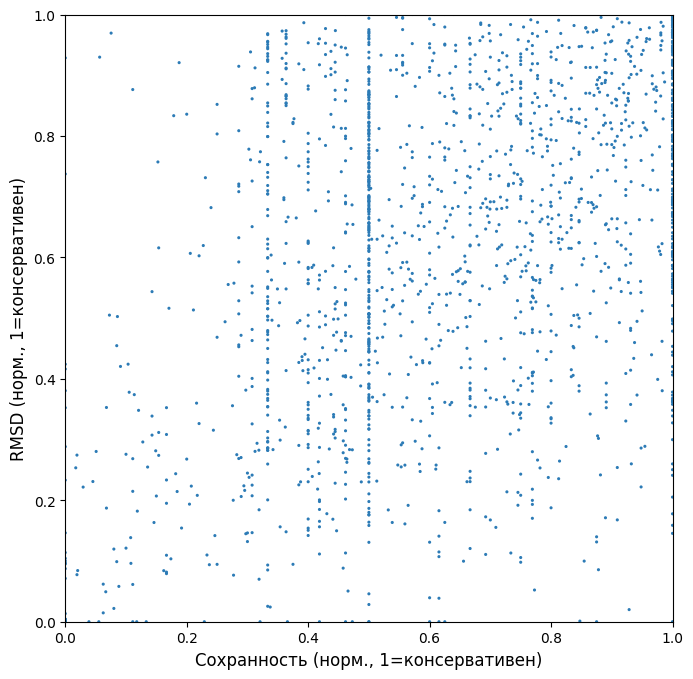

Энтропия vs RMSD: Spearman r=0.232, p=8.70e-66, точек=5297


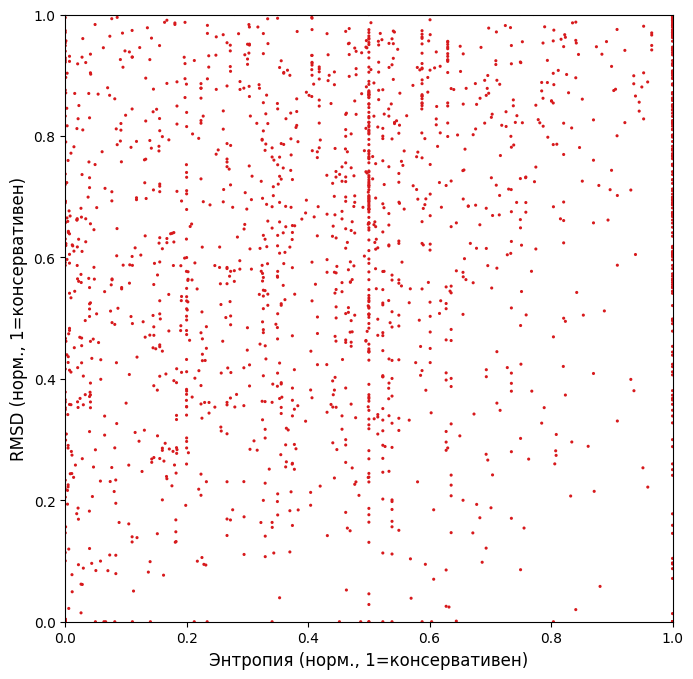

In [10]:
import json, numpy as np
from scipy import stats
import matplotlib.pyplot as plt

with open('per_residue_variance_atlas.json') as f: variance_data = json.load(f)
with open('per_residue_rmsd_atlas.json') as f: rmsd_data = json.load(f)
with open('per_residue_entropy_raw_atlas.json') as f: entropy_data = json.load(f)

def calc_entropy(p):
    return 0.0 if p in (0,1) else -p*np.log2(p)-(1-p)*np.log2(1-p)

# Сохранность и RMSD 
contact_vs_rmsd = []
for key in variance_data:
    if key not in rmsd_data: continue
    for var_g, rmsd_g in zip(variance_data[key], rmsd_data[key]):
        residues = var_g['residues']
        con_vals = np.array([float(var_g['contact'].get(str(r), np.nan)) for r in residues])
        rmsd_vals = np.array([float(rmsd_g['distances'].get(str(r), np.nan)) for r in residues])
        valid = ~np.isnan(con_vals) & ~np.isnan(rmsd_vals)
        con_vals, rmsd_vals = con_vals[valid], rmsd_vals[valid]
        # FILTER: минимум 5 валидных значений
        if len(con_vals) < 5: continue
        con_norm = (con_vals-con_vals.min())/(con_vals.max()-con_vals.min()) if con_vals.max()>con_vals.min() else np.full_like(con_vals, 0.5)
        rmsd_norm = 1-(rmsd_vals-rmsd_vals.min())/(rmsd_vals.max()-rmsd_vals.min()) if rmsd_vals.max()>rmsd_vals.min() else np.full_like(rmsd_vals, 0.5)
        contact_vs_rmsd.extend(zip(con_norm, rmsd_norm))

contact_vs_rmsd = np.array(contact_vs_rmsd)
r_cr, p_cr = stats.spearmanr(contact_vs_rmsd[:,0], contact_vs_rmsd[:,1])
print(f"Сохранность vs RMSD: Spearman r={r_cr:.3f}, p={p_cr:.2e}, точек={len(contact_vs_rmsd)}")

fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(contact_vs_rmsd[::3,0], contact_vs_rmsd[::3,1], alpha=1, s=5, c='#2c7bb6', edgecolors='none')
ax.set_xlabel('Сохранность (норм., 1=консервативен)', fontsize=12)
ax.set_ylabel('RMSD (норм., 1=консервативен)', fontsize=12)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
plt.tight_layout(); plt.savefig('contact_vs_rmsd_scatter_atlas.png', dpi=150, bbox_inches='tight'); plt.show()

# Энтропия vs RMSD 
entropy_vs_rmsd = []
for key in entropy_data:
    if key not in rmsd_data: continue
    for ent_g, rmsd_g in zip(entropy_data[key], rmsd_data[key]):
        residues = ent_g['residues']
        ent_vals = np.array([float(ent_g['entropy'].get(str(r), np.nan)) for r in residues])
        rmsd_vals = np.array([float(rmsd_g['distances'].get(str(r), np.nan)) for r in residues])
        valid = ~np.isnan(ent_vals) & ~np.isnan(rmsd_vals)
        ent_vals, rmsd_vals = ent_vals[valid], rmsd_vals[valid]
        if len(ent_vals) < 5: continue
        ent_norm = 1-(ent_vals-ent_vals.min())/(ent_vals.max()-ent_vals.min()) if ent_vals.max()>ent_vals.min() else np.full_like(ent_vals, 0.5)
        rmsd_norm = 1-(rmsd_vals-rmsd_vals.min())/(rmsd_vals.max()-rmsd_vals.min()) if rmsd_vals.max()>rmsd_vals.min() else np.full_like(rmsd_vals, 0.5)
        entropy_vs_rmsd.extend(zip(ent_norm, rmsd_norm))

entropy_vs_rmsd = np.array(entropy_vs_rmsd)
r_er, p_er = stats.spearmanr(entropy_vs_rmsd[:,0], entropy_vs_rmsd[:,1])
print(f"Энтропия vs RMSD: Spearman r={r_er:.3f}, p={p_er:.2e}, точек={len(entropy_vs_rmsd)}")

fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(entropy_vs_rmsd[::3,0], entropy_vs_rmsd[::3,1], alpha=1, s=5, c='#d7191c', edgecolors='none')
ax.set_xlabel('Энтропия (норм., 1=консервативен)', fontsize=12)
ax.set_ylabel('RMSD (норм., 1=консервативен)', fontsize=12)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
plt.tight_layout(); plt.savefig('entropy_vs_rmsd_scatter_atlas.png', dpi=150, bbox_inches='tight'); plt.show()

Сохранность vs RMSD: Spearman r = 0.355, p = 1.81e-157, точек = 5297
Энтропия vs RMSD: Spearman r = 0.232, p = 8.70e-66, точек = 5297
Дисперсия vs RMSD: Spearman r = 0.314, p = 2.97e-121, точек = 5297


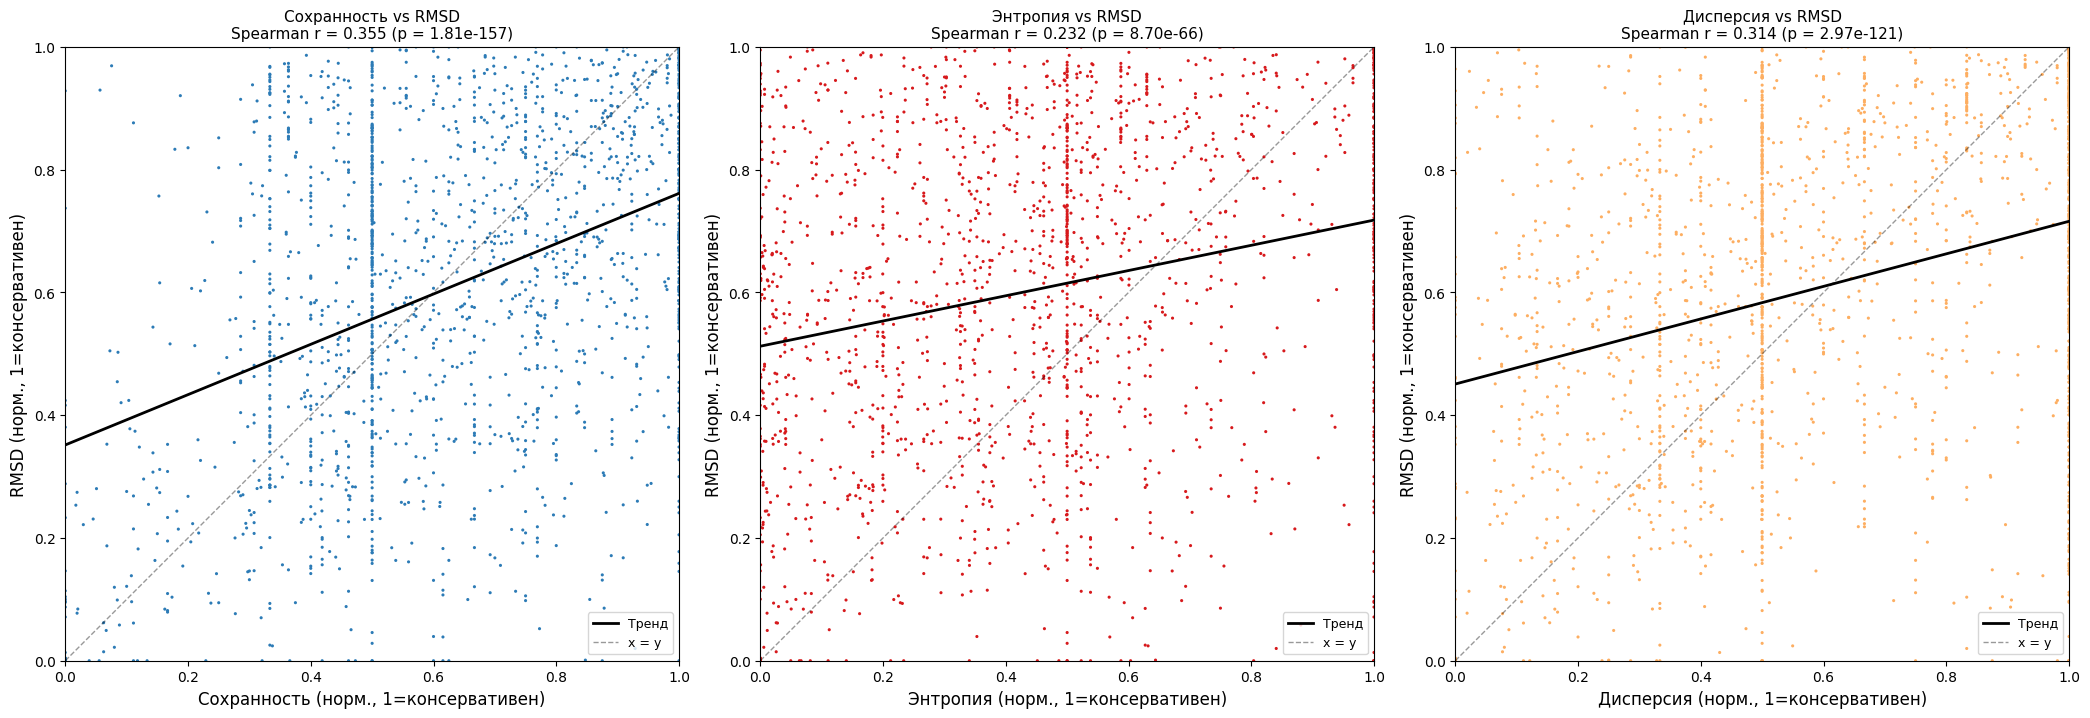


Сохранено: scatter_all_methods_vs_rmsd.png

Сравнение:
Метод           Spearman r   p-value     
--------------- ------------ ------------
Сохранность     0.355        1.81e-157   
Энтропия        0.232        8.70e-66    
Дисперсия       0.314        2.97e-121   


In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Загружаем данные

with open('per_residue_variance_atlas.json', 'r') as f:
    variance_data = json.load(f)

with open('per_residue_rmsd_atlas.json', 'r') as f:
    rmsd_data = json.load(f)

with open('per_residue_entropy_raw_atlas.json', 'r') as f:
    entropy_data = json.load(f)

# Энтропия

def calc_entropy(p):
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

# Собираем данные: Сохранность и RMSD

contact_vs_rmsd = []

for key in variance_data:
    if key not in rmsd_data:
        continue
    
    for var_g, rmsd_g in zip(variance_data[key], rmsd_data[key]):
        residues = var_g['residues']
        
        con_vals = np.array([float(var_g['contact'].get(str(r), np.nan)) for r in residues])
        rmsd_vals = np.array([float(rmsd_g['distances'].get(str(r), np.nan)) for r in residues])
        
        valid = ~np.isnan(con_vals) & ~np.isnan(rmsd_vals)
        con_vals, rmsd_vals = con_vals[valid], rmsd_vals[valid]
        
        if len(con_vals) < 5:
            continue
        
        # Нормировка
        if con_vals.max() > con_vals.min():
            con_norm = (con_vals - con_vals.min()) / (con_vals.max() - con_vals.min())
        else:
            con_norm = np.full_like(con_vals, 0.5)
        
        if rmsd_vals.max() > rmsd_vals.min():
            rmsd_norm = 1 - (rmsd_vals - rmsd_vals.min()) / (rmsd_vals.max() - rmsd_vals.min())
        else:
            rmsd_norm = np.full_like(rmsd_vals, 0.5)
        
        contact_vs_rmsd.extend(zip(con_norm, rmsd_norm))

contact_vs_rmsd = np.array(contact_vs_rmsd)
r_cr, p_cr = stats.spearmanr(contact_vs_rmsd[:, 0], contact_vs_rmsd[:, 1])
print(f"Сохранность vs RMSD: Spearman r = {r_cr:.3f}, p = {p_cr:.2e}, точек = {len(contact_vs_rmsd)}")

# Собираем данные: Энтропия и RMSD

entropy_vs_rmsd = []

for key in entropy_data:
    if key not in rmsd_data:
        continue
    
    for ent_g, rmsd_g in zip(entropy_data[key], rmsd_data[key]):
        residues = ent_g['residues']
        
        ent_vals = np.array([float(ent_g['entropy'].get(str(r), np.nan)) for r in residues])
        rmsd_vals = np.array([float(rmsd_g['distances'].get(str(r), np.nan)) for r in residues])
        
        valid = ~np.isnan(ent_vals) & ~np.isnan(rmsd_vals)
        ent_vals, rmsd_vals = ent_vals[valid], rmsd_vals[valid]
        
        if len(ent_vals) < 5:
            continue
        
        if ent_vals.max() > ent_vals.min():
            ent_norm = 1 - (ent_vals - ent_vals.min()) / (ent_vals.max() - ent_vals.min())
        else:
            ent_norm = np.full_like(ent_vals, 0.5)
        
        if rmsd_vals.max() > rmsd_vals.min():
            rmsd_norm = 1 - (rmsd_vals - rmsd_vals.min()) / (rmsd_vals.max() - rmsd_vals.min())
        else:
            rmsd_norm = np.full_like(rmsd_vals, 0.5)
        
        entropy_vs_rmsd.extend(zip(ent_norm, rmsd_norm))

entropy_vs_rmsd = np.array(entropy_vs_rmsd)
r_er, p_er = stats.spearmanr(entropy_vs_rmsd[:, 0], entropy_vs_rmsd[:, 1])
print(f"Энтропия vs RMSD: Spearman r = {r_er:.3f}, p = {p_er:.2e}, точек = {len(entropy_vs_rmsd)}")

# Собираем данные: Дисперсия и RMSD

variance_vs_rmsd = []

for key in variance_data:
    if key not in rmsd_data:
        continue
    
    for var_g, rmsd_g in zip(variance_data[key], rmsd_data[key]):
        residues = var_g['residues']
        
        var_vals = np.array([float(var_g['variance'].get(str(r), np.nan)) for r in residues])
        rmsd_vals = np.array([float(rmsd_g['distances'].get(str(r), np.nan)) for r in residues])
        
        valid = ~np.isnan(var_vals) & ~np.isnan(rmsd_vals)
        var_vals, rmsd_vals = var_vals[valid], rmsd_vals[valid]
        
        if len(var_vals) < 5:
            continue
        
        if var_vals.max() > var_vals.min():
            var_norm = 1 - (var_vals - var_vals.min()) / (var_vals.max() - var_vals.min())
        else:
            var_norm = np.full_like(var_vals, 0.5)
        
        if rmsd_vals.max() > rmsd_vals.min():
            rmsd_norm = 1 - (rmsd_vals - rmsd_vals.min()) / (rmsd_vals.max() - rmsd_vals.min())
        else:
            rmsd_norm = np.full_like(rmsd_vals, 0.5)
        
        variance_vs_rmsd.extend(zip(var_norm, rmsd_norm))

variance_vs_rmsd = np.array(variance_vs_rmsd)
r_vr, p_vr = stats.spearmanr(variance_vs_rmsd[:, 0], variance_vs_rmsd[:, 1])
print(f"Дисперсия vs RMSD: Spearman r = {r_vr:.3f}, p = {p_vr:.2e}, точек = {len(variance_vs_rmsd)}")

# Графики с линиями тренда

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

datasets = [
    (contact_vs_rmsd, 'Сохранность', '#2c7bb6', r_cr, p_cr),
    (entropy_vs_rmsd, 'Энтропия', '#d7191c', r_er, p_er),
    (variance_vs_rmsd, 'Дисперсия', '#fdae61', r_vr, p_vr)
]

for ax, (data, name, color, r_val, p_val) in zip(axes, datasets):
    # Scatter
    ax.scatter(data[::3, 0], data[::3, 1], alpha=1, s=5, c=color, edgecolors='none')
    
    # Линия тренда
    z = np.polyfit(data[:, 0], data[:, 1], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, p_line(x_line), 'k-', linewidth=2, label=f'Тренд')
    
    # x=y
    ax.plot(x_line, x_line, 'k--', linewidth=1, alpha=0.4, label='x = y')
    
    ax.set_xlabel(f'{name} (норм., 1=консервативен)', fontsize=12)
    ax.set_ylabel('RMSD (норм., 1=консервативен)', fontsize=12)
    ax.set_title(f'{name} vs RMSD\nSpearman r = {r_val:.3f} (p = {p_val:.2e})', fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('scatter_all_methods_vs_rmsd.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nСохранено: scatter_all_methods_vs_rmsd.png")
print("\nСравнение:")
print(f"{'Метод':<15} {'Spearman r':<12} {'p-value':<12}")
print(f"{'-'*15} {'-'*12} {'-'*12}")
print(f"{'Сохранность':<15} {r_cr:<12.3f} {p_cr:<12.2e}")
print(f"{'Энтропия':<15} {r_er:<12.3f} {p_er:<12.2e}")
print(f"{'Дисперсия':<15} {r_vr:<12.3f} {p_vr:<12.2e}")

In [6]:
import json, numpy as np, matplotlib.pyplot as plt, os

with open('per_residue_variance_atlas.json') as f: variance_data = json.load(f)
with open('per_residue_rmsd_atlas.json') as f: rmsd_data = json.load(f)

def calc_entropy(p):
    return 0.0 if p in (0,1) else -p*np.log2(p)-(1-p)*np.log2(1-p)

def normalize_row(row_vals, invert=True):
    valid = ~np.isnan(row_vals)
    if valid.sum() == 0: return row_vals
    vmin, vmax = np.nanmin(row_vals), np.nanmax(row_vals)
    if vmax > vmin:
        return 1-(row_vals-vmin)/(vmax-vmin) if invert else (row_vals-vmin)/(vmax-vmin)
    result = np.full_like(row_vals, 0.5); result[~valid] = np.nan; return result

output_folder = "heatmaps_4methodsnew"; os.makedirs(output_folder, exist_ok=True)

for key in variance_data:
    if key not in rmsd_data: continue
    var_groups, rmsd_groups = variance_data[key], rmsd_data[key]
    parts = key.split('|'); row_num = int(parts[0]); seq_label = '|'.join(parts[1:])
    
    for g_idx, (var_g, rmsd_g) in enumerate(zip(var_groups, rmsd_groups)):
        residues = var_g['residues']
        variance = {int(k): float(v) for k,v in var_g['variance'].items()}
        contact = {int(k): float(v) for k,v in var_g['contact'].items()}
        rmsd = {int(k): float(v) for k,v in rmsd_g['distances'].items()}
        entropy = {r: calc_entropy(contact[r]) for r in residues}
        
        n_res = len(residues)
        # FILTER: минимум 10 остатков
        if n_res < 10: continue
        
        row_var = np.array([variance.get(r, np.nan) for r in residues])
        row_ent = np.array([entropy.get(r, np.nan) for r in residues])
        row_con = np.array([contact.get(r, np.nan) for r in residues])
        row_rmsd = np.array([rmsd.get(r, np.nan) for r in residues])
        
        mat_variance = normalize_row(row_var, invert=True)
        mat_entropy = normalize_row(row_ent, invert=True)
        mat_contact = normalize_row(row_con, invert=False)
        mat_rmsd = normalize_row(row_rmsd, invert=True)
        
        fig, axes = plt.subplots(4, 1, figsize=(max(14, n_res*0.25), 10))
        cmap = plt.cm.RdYlBu
        
        for ax, (matrix, title) in zip(axes, [
            (mat_variance, 'Дисперсия'), (mat_entropy, 'Энтропия'),
            (mat_contact, 'Сохранность'), (mat_rmsd, 'RMSD')]):
            im = ax.imshow(matrix.reshape(1,-1), aspect='auto', cmap=cmap, vmin=0, vmax=1)
            ax.set_xticks(range(n_res)); ax.set_xticklabels(residues, rotation=90, fontsize=5)
            ax.set_yticks([]); ax.set_ylabel(title, fontsize=8, fontweight='bold')
        
        fig.suptitle(f'Строка {row_num}: {seq_label[:50]}...\nГруппа {g_idx+1}: {residues[0]}-{residues[-1]} ({n_res} ост.)\nКРАСНЫЙ=консервативен, СИНИЙ=вариабелен', fontsize=9, fontweight='bold')
        plt.tight_layout()
        safe = f"seq{row_num}_{seq_label[:20].replace(' ','_').replace('/','_')}_g{g_idx+1}"
        plt.savefig(os.path.join(output_folder, f"{safe}.png"), dpi=150, bbox_inches='tight'); plt.close()

print(f"Готово: {output_folder}/")

Готово: heatmaps_4methodsnew/



ДИСПЕРСИЯ: Kruskal-Wallis H=33.74, p=0.000008


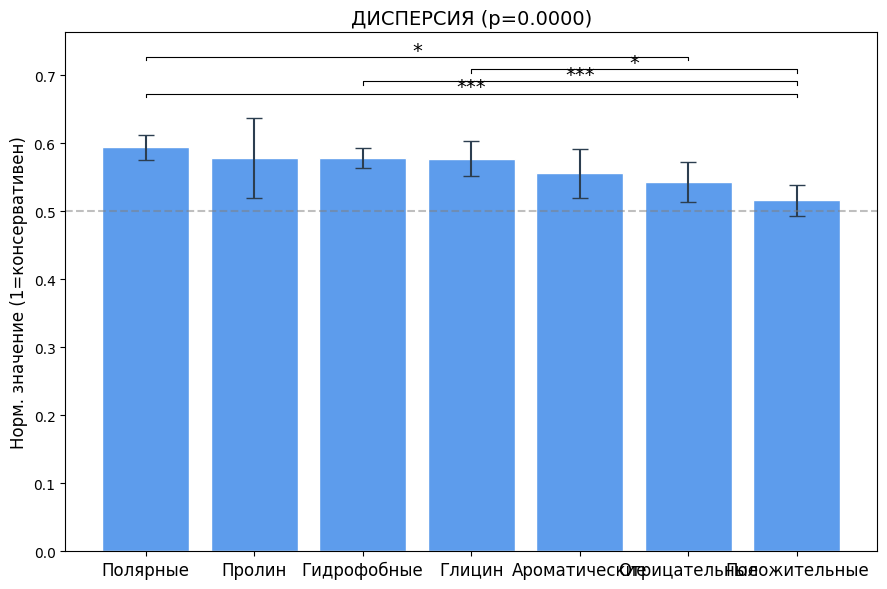


ЭНТРОПИЯ: Kruskal-Wallis H=19.57, p=0.003297


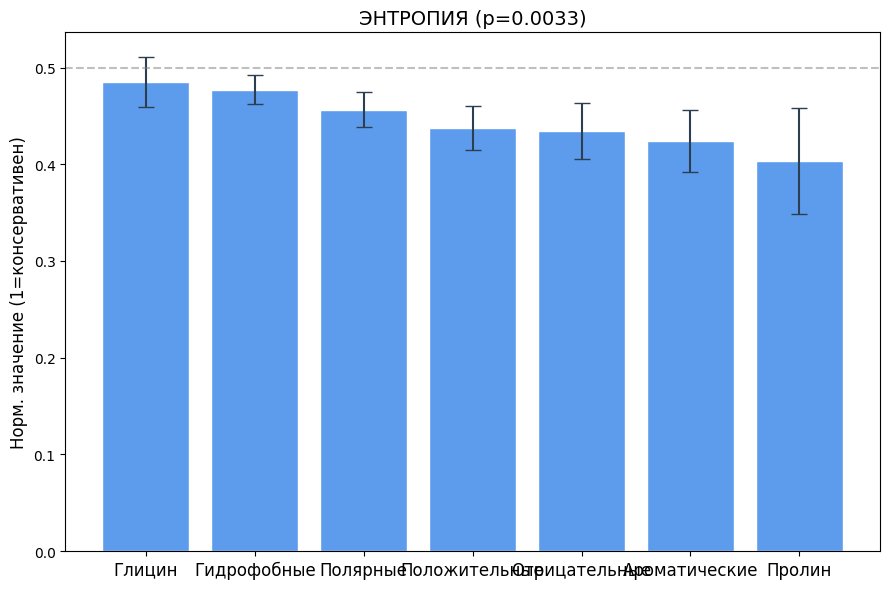


СОХРАННОСТЬ: Kruskal-Wallis H=35.93, p=0.000003


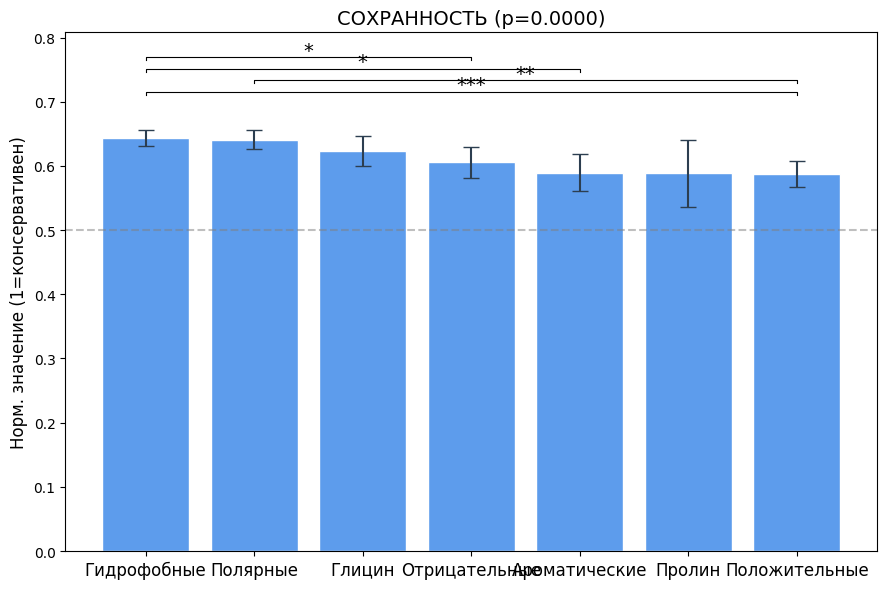


RMSD: Kruskal-Wallis H=32.99, p=0.000011


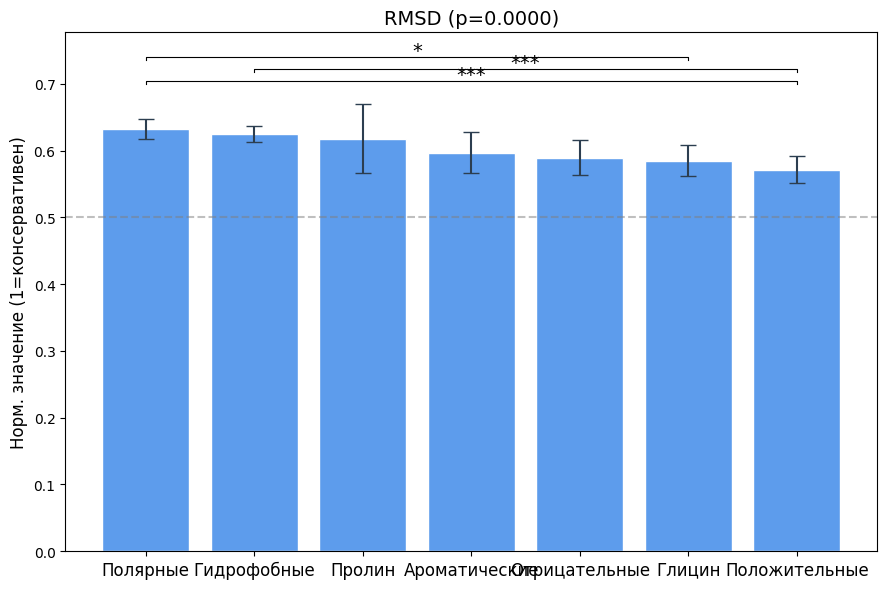

In [5]:
import json, numpy as np, pandas as pd
from scipy import stats
from collections import defaultdict

with open('per_residue_variance_atlas.json') as f: variance_data = json.load(f)
with open('per_residue_rmsd_atlas.json') as f: rmsd_data = json.load(f)

csv_path = r"C:\Users\User\Downloads\sequences_merged_with_links.csv"
df = pd.read_csv(csv_path, delimiter=';')
seq_dict = {}
for row_idx in range(len(df)):
    seq = df.iloc[row_idx]['sequence']
    if isinstance(seq, str): seq_dict[row_idx+1] = seq.upper()

def calc_entropy(p):
    return 0.0 if p in (0,1) else -p*np.log2(p)-(1-p)*np.log2(1-p)

aa_groups = {'Гидрофобные':'AVLIFMW','Полярные':'STNQC','Положительные':'KRH',
             'Отрицательные':'DE','Глицин':'G','Пролин':'P','Ароматические':'FYW'}

aa_data_all = {name: defaultdict(list) for name in ['variance','entropy','contact','rmsd']}

for key in variance_data:
    if key not in rmsd_data: continue
    row_num = int(key.split('|')[0]); full_seq = seq_dict.get(row_num,'')
    if not full_seq: continue
    
    for var_g, rmsd_g in zip(variance_data[key], rmsd_data[key]):
        residues = var_g['residues']
        var_vals, ent_vals, con_vals, rmsd_vals, aa_list = [], [], [], [], []
        
        for resnum in residues:
            res_str = str(resnum)
            if (res_str in var_g['variance'] and res_str in var_g['contact'] 
                and res_str in rmsd_g['distances'] and 1 <= resnum <= len(full_seq)):
                p = float(var_g['contact'][res_str])
                var_vals.append(float(var_g['variance'][res_str]))
                ent_vals.append(calc_entropy(p))
                con_vals.append(p)
                rmsd_vals.append(float(rmsd_g['distances'][res_str]))
                aa_list.append(full_seq[resnum-1])
        
        if len(var_vals) < 5: continue
        
        def norm(vals, invert=True):
            v = np.array(vals); vmin, vmax = np.min(v), np.max(v)
            if vmax>vmin: return 1-(v-vmin)/(vmax-vmin) if invert else (v-vmin)/(vmax-vmin)
            return np.full_like(v, 0.5)
        
        var_n = norm(var_vals, True); ent_n = norm(ent_vals, True)
        con_n = norm(con_vals, False); rmsd_n = norm(rmsd_vals, True)
        
        for i, aa in enumerate(aa_list):
            aa_data_all['variance'][aa].append(var_n[i])
            aa_data_all['entropy'][aa].append(ent_n[i])
            aa_data_all['contact'][aa].append(con_n[i])
            aa_data_all['rmsd'][aa].append(rmsd_n[i])

# Графики для каждого метода
from scipy.stats import rankdata
def dunn_test(groups):
    all_data = np.concatenate(groups); ranks = rankdata(all_data)
    gr_ranks, gr_n = [], []; start = 0
    for g in groups:
        n = len(g); gr_ranks.append(ranks[start:start+n]); gr_n.append(n); start += n
    results = []
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            R_i, R_j = np.mean(gr_ranks[i]), np.mean(gr_ranks[j])
            SE = np.sqrt((len(all_data)*(len(all_data)+1)/12)*(1/gr_n[i]+1/gr_n[j]))
            results.append({'i':i,'j':j,'p':2*(1-stats.norm.cdf(abs((R_i-R_j)/SE)))})
    return results

for metric_name, aa_data in [('ДИСПЕРСИЯ', aa_data_all['variance']),
                              ('ЭНТРОПИЯ', aa_data_all['entropy']),
                              ('СОХРАННОСТЬ', aa_data_all['contact']),
                              ('RMSD', aa_data_all['rmsd'])]:
    group_vals, group_names = [], []
    for gn, aas in aa_groups.items():
        vals = []; 
        for aa in aas:
            if aa in aa_data: vals.extend(aa_data[aa])
        if vals: group_vals.append(vals); group_names.append(gn)
    
    if len(group_vals)<2: continue
    
    H, p = stats.kruskal(*group_vals)
    print(f"\n{'='*50}\n{metric_name}: Kruskal-Wallis H={H:.2f}, p={p:.6f}\n{'='*50}")
    
    means = [np.mean(v) for v in group_vals]
    sems = [np.std(v)/np.sqrt(len(v)) for v in group_vals]
    cis = [1.96*s for s in sems]
    
    sorted_idx = np.argsort(means)[::-1]
    
    dunn_res = dunn_test(group_vals)
    n_comp = len(dunn_res)
    sig_pairs = []
    for r in dunn_res:
        pc = min(r['p']*n_comp, 1.0)
        if pc < 0.05: sig_pairs.append((r['i'], r['j'], pc))
    
    fig, ax = plt.subplots(figsize=(9,6))
    x_pos = range(len(group_names))
    ax.bar(x_pos, [means[i] for i in sorted_idx], color='#5D9CEC', edgecolor='white')
    ax.errorbar(x_pos, [means[i] for i in sorted_idx], yerr=[cis[i] for i in sorted_idx],
                fmt='none', ecolor='#2c3e50', capsize=6)
    ax.set_xticks(x_pos); ax.set_xticklabels([group_names[i] for i in sorted_idx], fontsize=12)
    ax.set_ylabel('Норм. значение (1=консервативен)', fontsize=12)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    ax.set_title(f'{metric_name} (p={p:.4f})', fontsize=14)
    
    # значимость
    if sig_pairs:
        old_to_new = {old:new for new,old in enumerate(sorted_idx)}
        y_top = max(means) + max(cis) + 0.02
        for idx, (i, j, pc) in enumerate(sorted(sig_pairs, key=lambda x: x[2])):
            ni, nj = old_to_new[i], old_to_new[j]
            if ni > nj: ni, nj = nj, ni
            y = y_top + idx*0.018
            ax.plot([ni,ni,nj,nj], [y-0.005,y,y,y-0.005], 'k-', linewidth=0.8)
            stars = '***' if pc<0.001 else '**' if pc<0.01 else '*'
            ax.text((ni+nj)/2, y+0.002, stars, ha='center', fontsize=14)
    
    plt.tight_layout(); plt.savefig(f'aa_groups_{metric_name.lower()}_atlas.png', dpi=200); plt.show()

КОРРЕЛЯЦИИ ПО ГРУППАМ
Дисперсия vs Энтропия            : r=0.625±0.452, n=75, отриц:15%
Дисперсия vs Сохранность         : r=0.467±0.636, n=75, отриц:28%
Дисперсия vs RMSD                : r=0.323±0.413, n=75, отриц:21%
Энтропия vs Сохранность         : r=0.407±0.871, n=76, отриц:30%
Энтропия vs RMSD                : r=0.298±0.486, n=76, отриц:32%
Сохранность vs RMSD                : r=0.515±0.309, n=76, отриц:4%


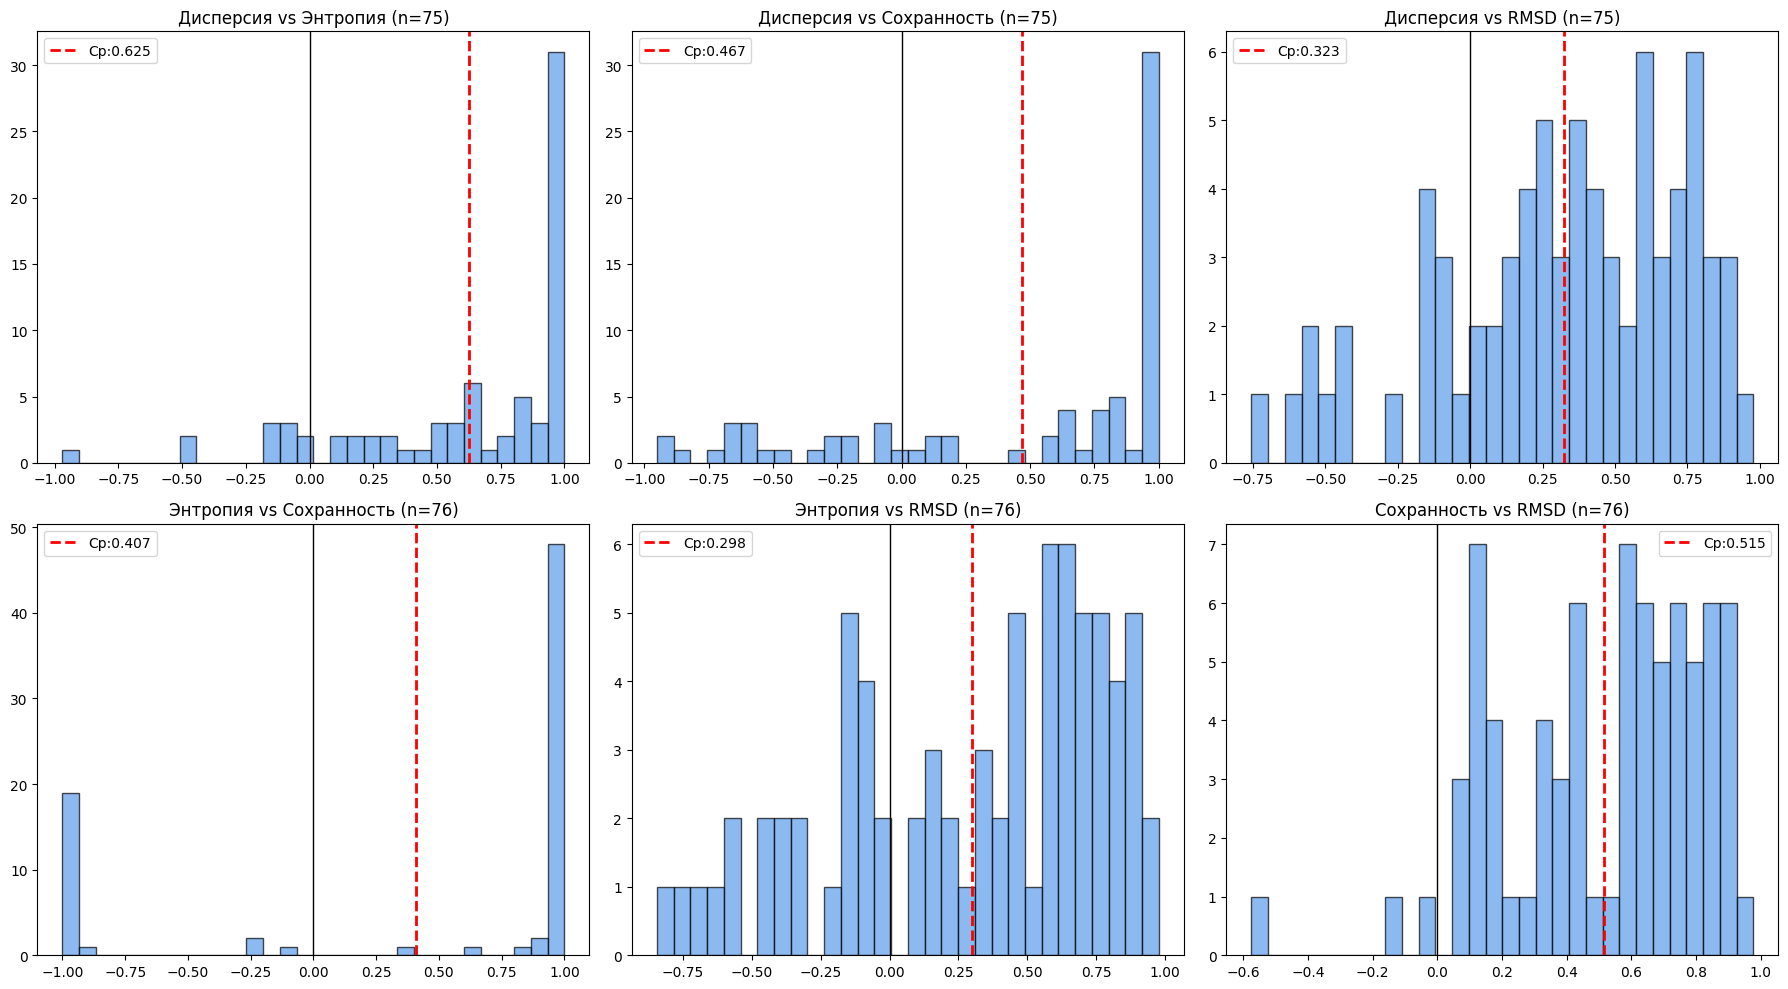

In [7]:
import json, numpy as np
from scipy import stats
import matplotlib.pyplot as plt

with open('per_residue_variance_atlas.json') as f: variance_data = json.load(f)
with open('per_residue_rmsd_atlas.json') as f: rmsd_data = json.load(f)

def calc_entropy(p):
    return 0.0 if p in (0,1) else -p*np.log2(p)-(1-p)*np.log2(1-p)

pairs = [('Дисперсия','Энтропия'),('Дисперсия','Сохранность'),('Дисперсия','RMSD'),
         ('Энтропия','Сохранность'),('Энтропия','RMSD'),('Сохранность','RMSD')]
group_correlations = {p:[] for p in pairs}

for key in variance_data:
    if key not in rmsd_data: continue
    for var_g, rmsd_g in zip(variance_data[key], rmsd_data[key]):
        residues = var_g['residues']
        var_vals, ent_vals, con_vals, rmsd_vals = [], [], [], []
        for resnum in residues:
            res_str = str(resnum)
            if (res_str in var_g['variance'] and res_str in var_g['contact'] 
                and res_str in rmsd_g['distances']):
                p = float(var_g['contact'][res_str])
                var_vals.append(float(var_g['variance'][res_str]))
                ent_vals.append(calc_entropy(p))
                con_vals.append(p)
                rmsd_vals.append(float(rmsd_g['distances'][res_str]))
        
        if len(var_vals) < 5: continue
        
        def norm(vals, invert=True):
            v = np.array(vals); vmin, vmax = np.min(v), np.max(v)
            if vmax>vmin: return 1-(v-vmin)/(vmax-vmin) if invert else (v-vmin)/(vmax-vmin)
            return np.full_like(v, 0.5)
        
        data = {'Дисперсия':norm(var_vals,True), 'Энтропия':norm(ent_vals,True),
                'Сохранность':norm(con_vals,False), 'RMSD':norm(rmsd_vals,True)}
        
        for n1, n2 in pairs:
            # FILTER: исключаем группы с одинаковыми значениями
            if len(data[n1])>=5 and len(set(data[n1]))>1 and len(set(data[n2]))>1:
                r, _ = stats.spearmanr(data[n1], data[n2])
                if not np.isnan(r): group_correlations[(n1,n2)].append(r)

print(f"{'='*70}")
print("КОРРЕЛЯЦИИ ПО ГРУППАМ")
print(f"{'='*70}")
for n1, n2 in pairs:
    c = group_correlations[(n1,n2)]
    if c:
        print(f"{n1} vs {n2:<20}: r={np.mean(c):.3f}±{np.std(c):.3f}, n={len(c)}, отриц:{100*sum(1 for x in c if x<0)/len(c):.0f}%")

fig, axes = plt.subplots(2,3,figsize=(18,10)); axes = axes.flatten()
for idx, (n1,n2) in enumerate(pairs):
    c = group_correlations[(n1,n2)]
    ax = axes[idx]
    if c:
        ax.hist(c, bins=30, edgecolor='black', alpha=0.7, color='#5D9CEC')
        ax.axvline(np.mean(c), color='red', linestyle='--', linewidth=2, label=f'Ср:{np.mean(c):.3f}')
        ax.axvline(0, color='black', linewidth=1)
    ax.set_title(f'{n1} vs {n2} (n={len(c)})'); ax.legend()
plt.tight_layout(); plt.savefig('group_correlations_hist_atlas.png', dpi=150); plt.show()

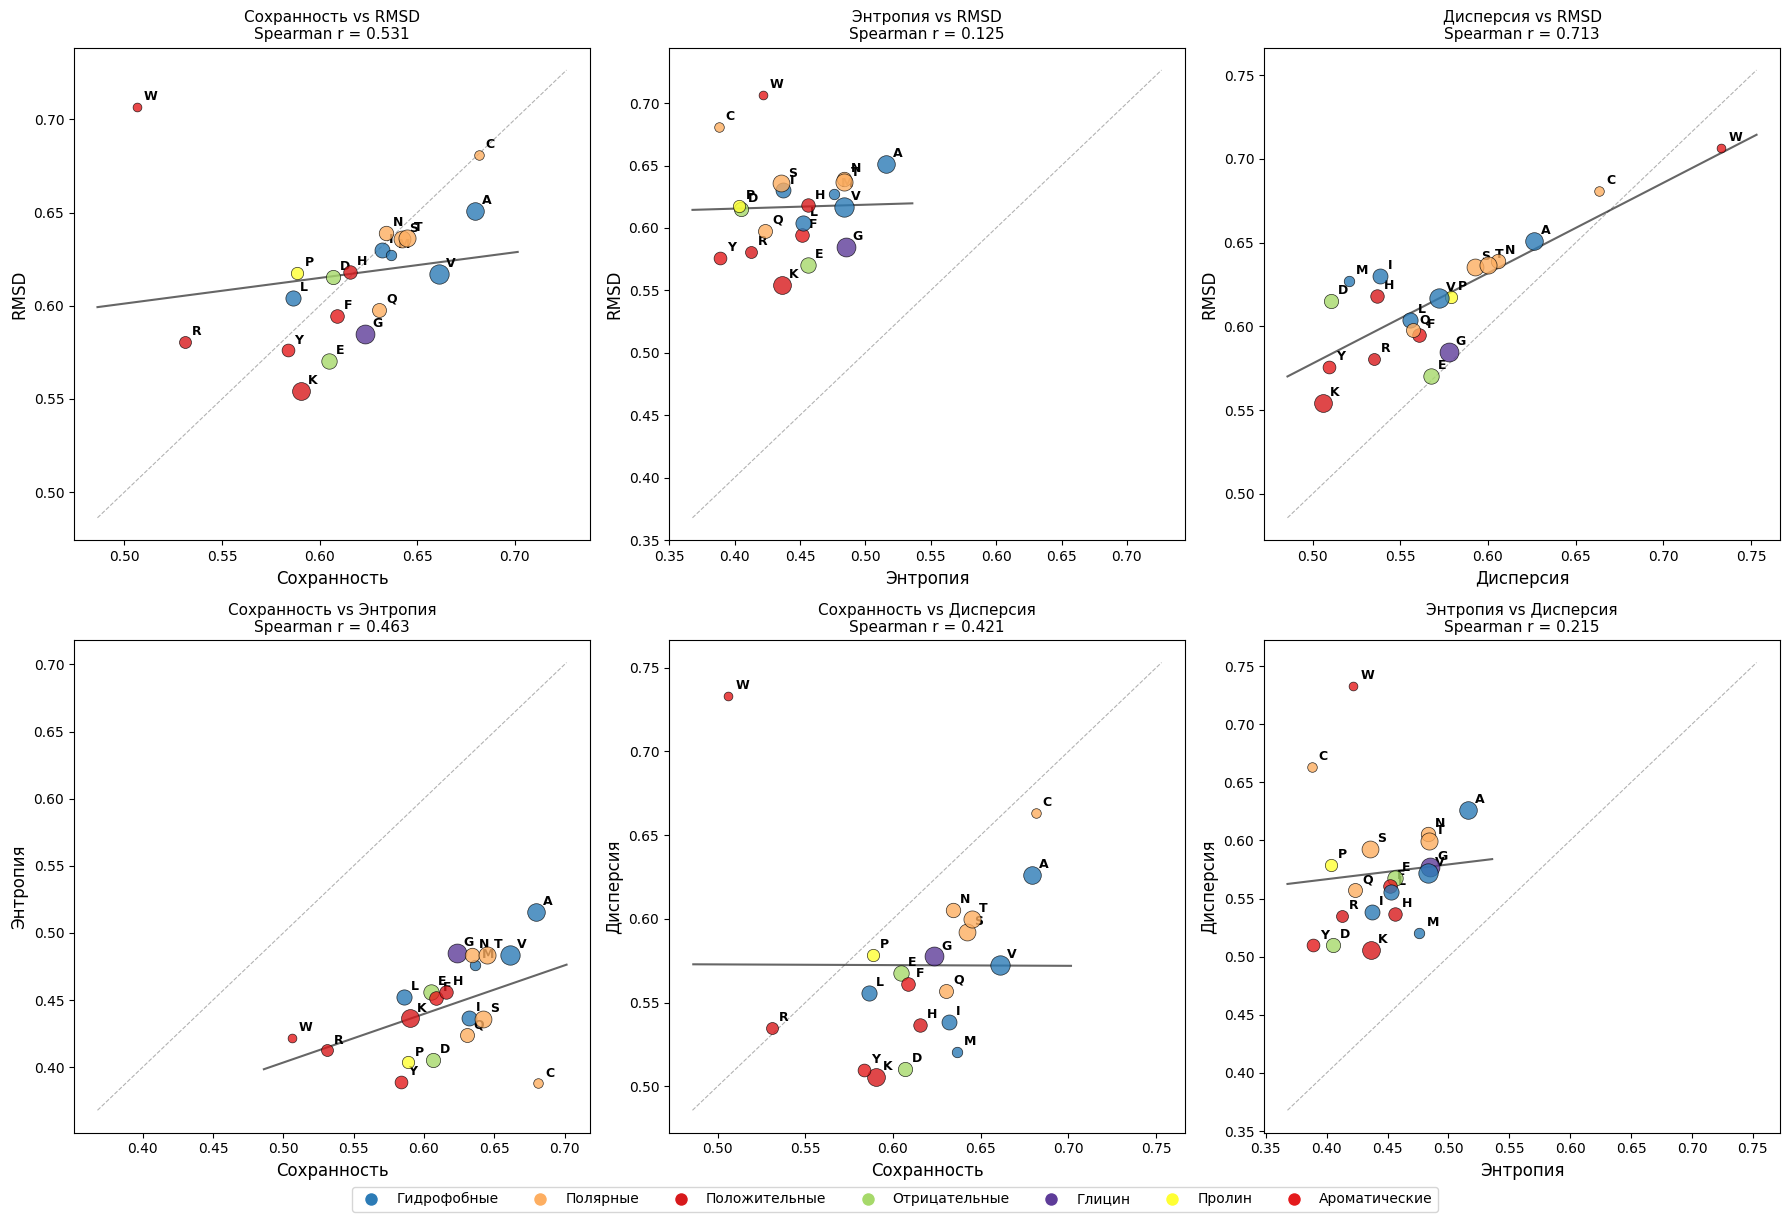

Сохранено: aa_bubble_plots.png


In [13]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict
import pandas as pd

# данные

with open('per_residue_variance_atlas.json', 'r') as f:
    variance_data = json.load(f)

with open('per_residue_rmsd_atlas.json', 'r') as f:
    rmsd_data = json.load(f)

csv_path = r"C:\Users\User\Downloads\sequences_merged_with_links.csv"
df = pd.read_csv(csv_path, delimiter=';')

seq_dict = {}
for row_idx in range(len(df)):
    seq = df.iloc[row_idx]['sequence']
    if isinstance(seq, str):
        seq_dict[row_idx + 1] = seq.upper()

# Энтропия

def calc_entropy(p):
    if p == 0 or p == 1:
        return 0.0
    return -p * np.log2(p) - (1-p) * np.log2(1-p)

# нормированные значения

aa_variance = defaultdict(list)
aa_entropy = defaultdict(list)
aa_contact = defaultdict(list)
aa_rmsd = defaultdict(list)

for key in variance_data:
    if key not in rmsd_data:
        continue
    
    row_num = int(key.split('|')[0])
    full_seq = seq_dict.get(row_num, '')
    if not full_seq:
        continue
    
    var_groups = variance_data[key]
    rmsd_groups = rmsd_data[key]
    
    for var_g, rmsd_g in zip(var_groups, rmsd_groups):
        residues = var_g['residues']
        variance = var_g['variance']
        contact = var_g['contact']
        rmsd = rmsd_g['distances']
        
        var_vals, ent_vals, con_vals, rmsd_vals, aa_list = [], [], [], [], []
        
        for resnum in residues:
            res_str = str(resnum)
            if (res_str in variance and res_str in contact and res_str in rmsd
                and 1 <= resnum <= len(full_seq)):
                
                p = float(contact[res_str])
                var_vals.append(float(variance[res_str]))
                ent_vals.append(calc_entropy(p))
                con_vals.append(p)
                rmsd_vals.append(float(rmsd[res_str]))
                aa_list.append(full_seq[resnum - 1])
        
        if len(var_vals) < 5:
            continue
        
        def norm_group(vals, invert=True):
            v = np.array(vals)
            vmin = np.min(v)
            vmax = np.max(v)
            if vmax > vmin:
                return 1 - (v - vmin) / (vmax - vmin) if invert else (v - vmin) / (vmax - vmin)
            return np.full_like(v, 0.5)
        
        var_norm = norm_group(var_vals, invert=True)
        ent_norm = norm_group(ent_vals, invert=True)
        con_norm = norm_group(con_vals, invert=False)
        rmsd_norm = norm_group(rmsd_vals, invert=True)
        
        for i, aa in enumerate(aa_list):
            aa_variance[aa].append(var_norm[i])
            aa_entropy[aa].append(ent_norm[i])
            aa_contact[aa].append(con_norm[i])
            aa_rmsd[aa].append(rmsd_norm[i])

# Средние по аминокислотам

standard_aa = 'ACDEFGHIKLMNPQRSTVWY'

aa_means = {}
aa_counts = {}

for aa in standard_aa:
    if aa in aa_rmsd and len(aa_rmsd[aa]) >= 5:
        aa_means[aa] = {
            'variance': np.mean(aa_variance[aa]),
            'entropy': np.mean(aa_entropy[aa]),
            'contact': np.mean(aa_contact[aa]),
            'rmsd': np.mean(aa_rmsd[aa])
        }
        aa_counts[aa] = len(aa_rmsd[aa])

# Группы аминокислот

aa_groups = {
    'Гидрофобные': 'AVLIFMW',
    'Полярные': 'STNQC',
    'Положительные': 'KRH',
    'Отрицательные': 'DE',
    'Глицин': 'G',
    'Пролин': 'P',
    'Ароматические': 'FYW'
}

group_colors = {
    'Гидрофобные': '#2c7bb6',
    'Полярные': '#fdae61',
    'Положительные': '#d7191c',
    'Отрицательные': '#a6d96a',
    'Глицин': '#5e3c99',
    'Пролин': '#ffff33',
    'Ароматические': '#e41a1c'
}

aa_to_group = {}
aa_to_color = {}
for group, aas in aa_groups.items():
    for aa in aas:
        aa_to_group[aa] = group
        aa_to_color[aa] = group_colors[group]

# Графики

pairs = [
    ('contact', 'rmsd', 'Сохранность', 'RMSD'),
    ('entropy', 'rmsd', 'Энтропия', 'RMSD'),
    ('variance', 'rmsd', 'Дисперсия', 'RMSD'),
    ('contact', 'entropy', 'Сохранность', 'Энтропия'),
    ('contact', 'variance', 'Сохранность', 'Дисперсия'),
    ('entropy', 'variance', 'Энтропия', 'Дисперсия')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (method1, method2, label1, label2) in enumerate(pairs):
    ax = axes[idx]
    
    for aa in aa_means:
        x = aa_means[aa][method1]
        y = aa_means[aa][method2]
        size = np.sqrt(aa_counts[aa]) * 8
        color = aa_to_color.get(aa, '#999999')
        
        ax.scatter(x, y, s=size, c=color, alpha=0.8, edgecolors='black', linewidth=0.5, zorder=5)
        ax.annotate(aa, (x, y), xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
    
    # Корреляция
    x_vals = [aa_means[aa][method1] for aa in aa_means]
    y_vals = [aa_means[aa][method2] for aa in aa_means]
    r, p = stats.spearmanr(x_vals, y_vals)
    
    # Линия тренда
    z = np.polyfit(x_vals, y_vals, 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(min(x_vals)-0.02, max(x_vals)+0.02, 100)
    ax.plot(x_line, p_line(x_line), 'k-', linewidth=1.5, alpha=0.6)
    
    # x=y
    all_min = min(min(x_vals), min(y_vals)) - 0.02
    all_max = max(max(x_vals), max(y_vals)) + 0.02
    ax.plot([all_min, all_max], [all_min, all_max], 'k--', linewidth=0.8, alpha=0.3)
    
    ax.set_xlabel(label1, fontsize=12)
    ax.set_ylabel(label2, fontsize=12)
    ax.set_title(f'{label1} vs {label2}\nSpearman r = {r:.3f}', fontsize=11)

# Легенды
legend_elements = []
for group, color in group_colors.items():
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                       markerfacecolor=color, markersize=10, label=group))
fig.legend(handles=legend_elements, loc='lower center', ncol=7, fontsize=10, 
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('aa_bubble_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Сохранено: aa_bubble_plots.png")